In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Path to checkpoint results (adjust as needed)
checkpoint_dir = Path('/Volumes/Amirali/hidden_states/experiments/baseline_v5_001/matrix_checkpoint')
results_dir = checkpoint_dir / 'per_entry_results'
csv_files = list(results_dir.glob('*_layer_probe_results.csv'))

In [2]:
frames = []
full = None

In [3]:

for f in csv_files:
    # Try multiple encodings
    try:
        df = pd.read_csv(f, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(f, encoding='latin-1')
    # Drop unwanted index column if present
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)
    frames.append(df)

In [4]:
if frames:
    full = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(full)} rows from {len(frames)} files.")
    print("Models:", full['model'].unique())
    print("Datasets:", full['dataset'].unique())
    print("Task types:", full['task_type'].unique())
else :
    print("No checkpoint result files found.")
    exit()
    

Loaded 660 rows from 16 files.
Models: ['google/electra-small-discriminator' 'FacebookAI/roberta-base'
 'distilbert/distilbert-base-uncased' 'microsoft/deberta-v3-small'
 'google-bert/bert-base-uncased' 'EleutherAI/gpt-neo-125m'
 'facebook/opt-125m']
Datasets: ['ISEAR' 'goEmo']
Task types: ['single_label' 'multi_label']


In [5]:
# Display a sample
if full is not None:
    display(full.head())

,repeat,seed,layer,layer_index,relative_layer_depth,probe,probe_type,probe_complexity,task_type,input_dim,...,test_micro_f1,test_micro_precision,test_micro_recall,test_hamming_loss,test_hamming_score,test_macro_jaccard,test_roc_auc_macro,test_labels_with_positive_support,test_labels_with_negative_support,test_labels_with_both_support
0,0,329176201,layer_0,0,0.000000,linear_logistic,logistic,linear,single_label,256,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,3129711444,layer_0,0,0.000000,mlp_1_hidden,mlp,1_hidden,single_label,256,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,3280942911,layer_0,0,0.000000,mlp_2_hidden,mlp,2_hidden,single_label,256,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,3349341881,layer_0,0,0.000000,mlp_3_hidden,mlp,3_hidden,single_label,256,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,329177198,layer_1,1,0.083333,linear_logistic,logistic,linear,single_label,256,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
metric_cols = [c for c in full.columns if c.startswith('test_') and not c.startswith('test_labels_')]
print("\nAvailable test metrics:")
print(metric_cols)


Available test metrics:
['test_n', 'test_accuracy', 'test_balanced_accuracy', 'test_macro_f1', 'test_weighted_f1', 'test_macro_precision', 'test_macro_recall', 'test_mcc', 'test_cohen_kappa', 'test_log_loss', 'test_log_loss_score', 'test_roc_auc_ovr_macro', 'test_average_precision_macro', 'test_exact_match_accuracy', 'test_micro_f1', 'test_micro_precision', 'test_micro_recall', 'test_hamming_loss', 'test_hamming_score', 'test_macro_jaccard', 'test_roc_auc_macro']


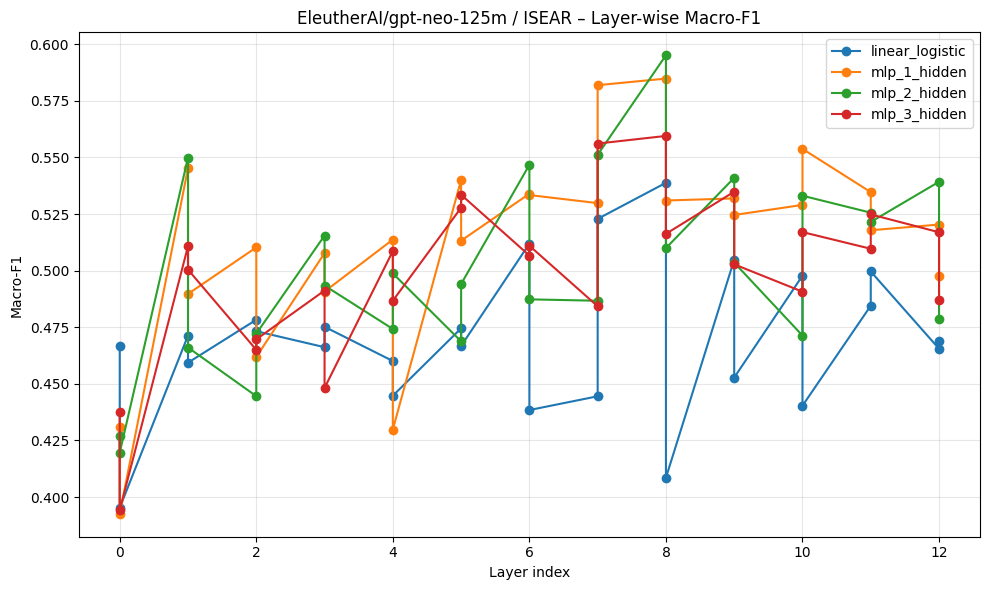

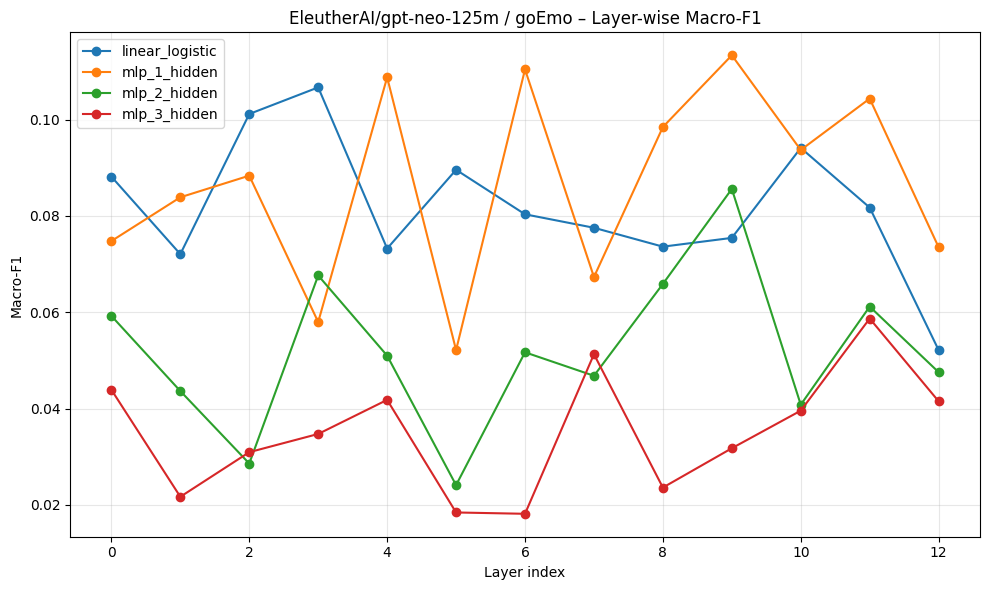

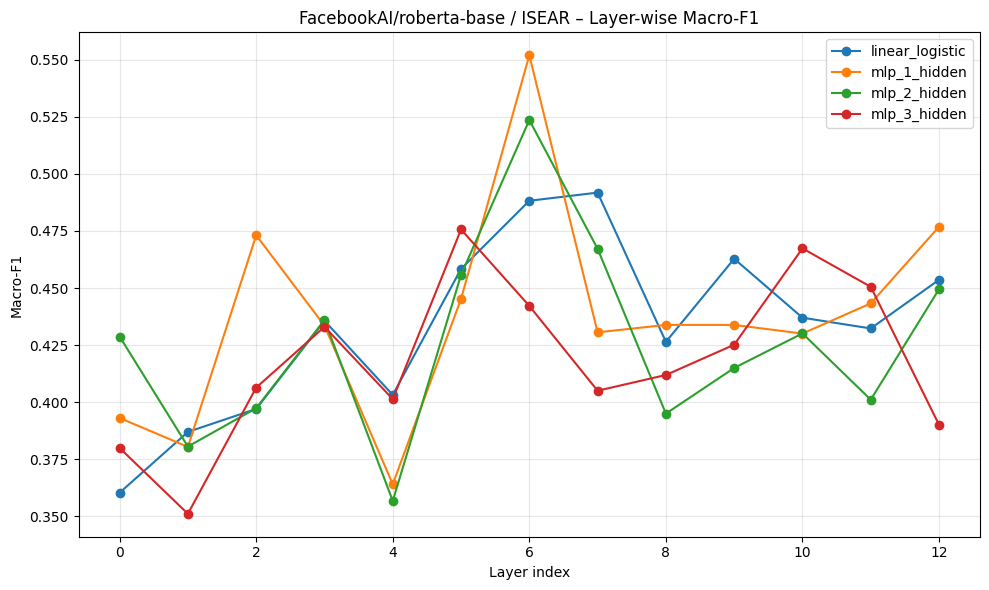

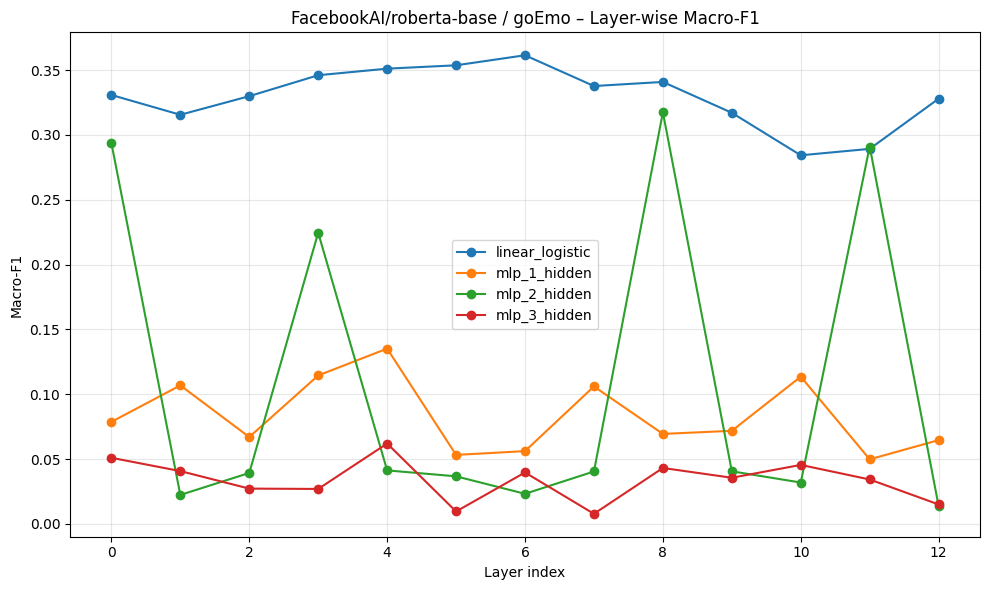

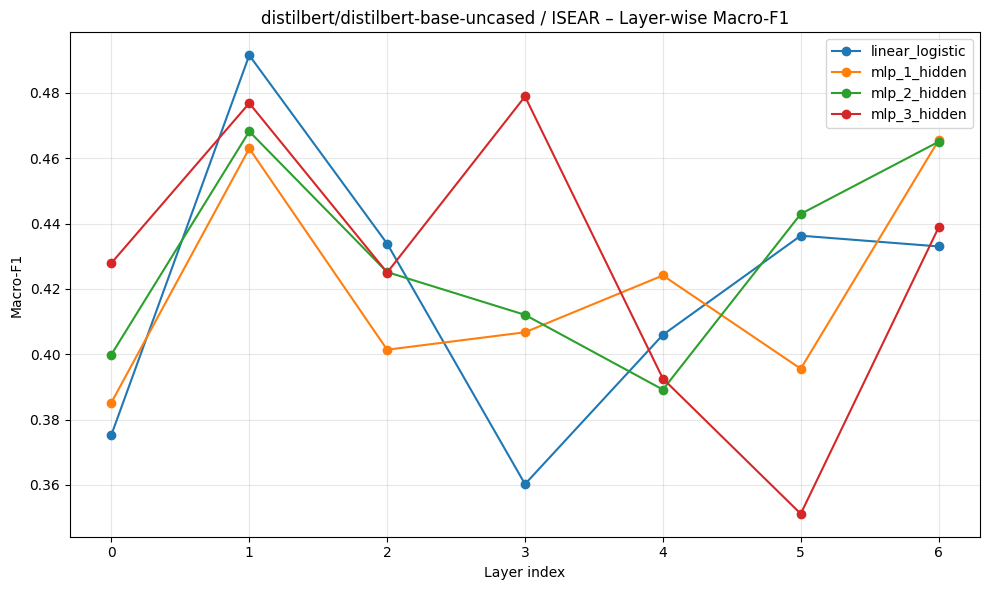

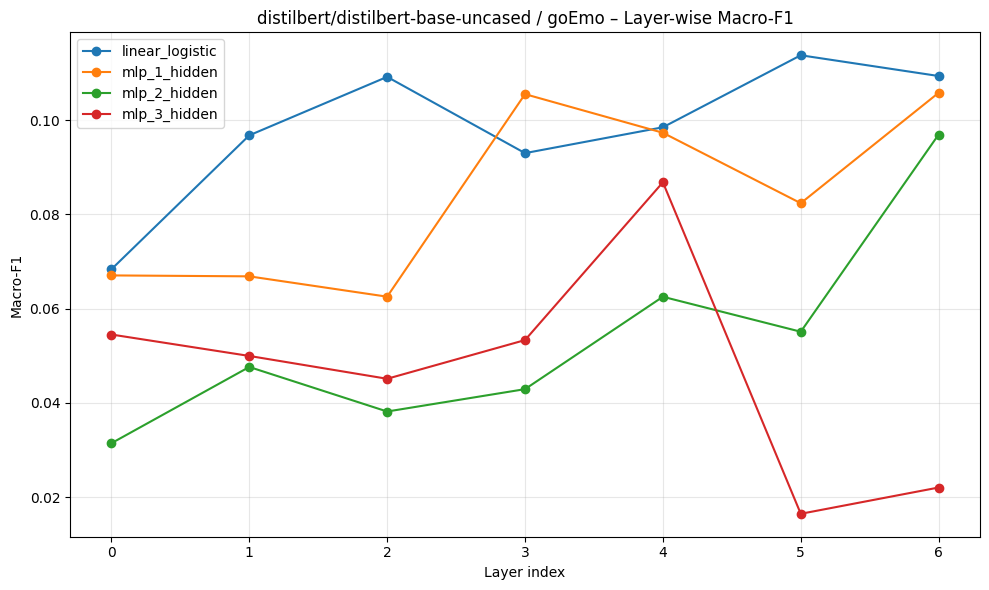

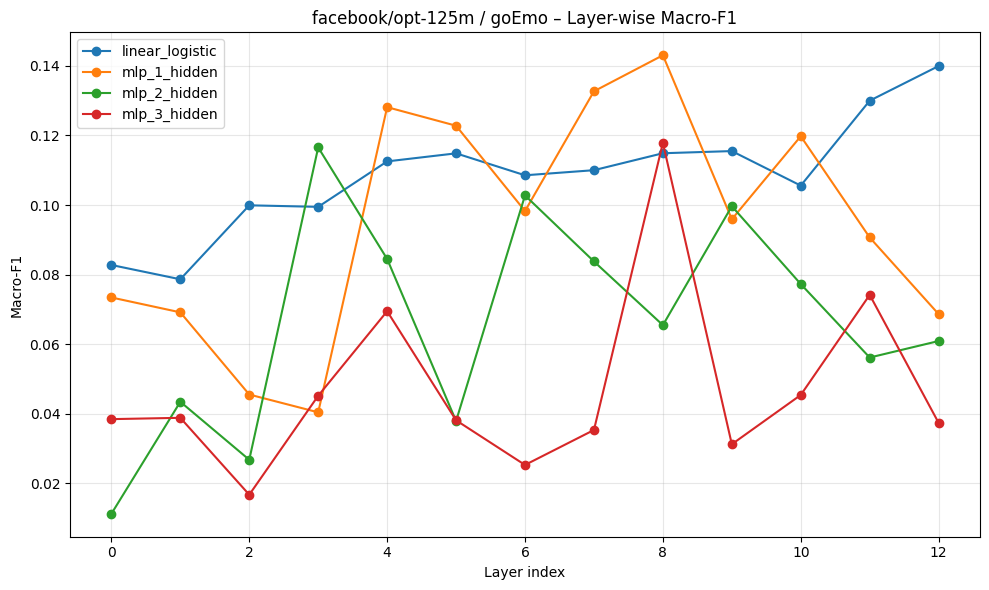

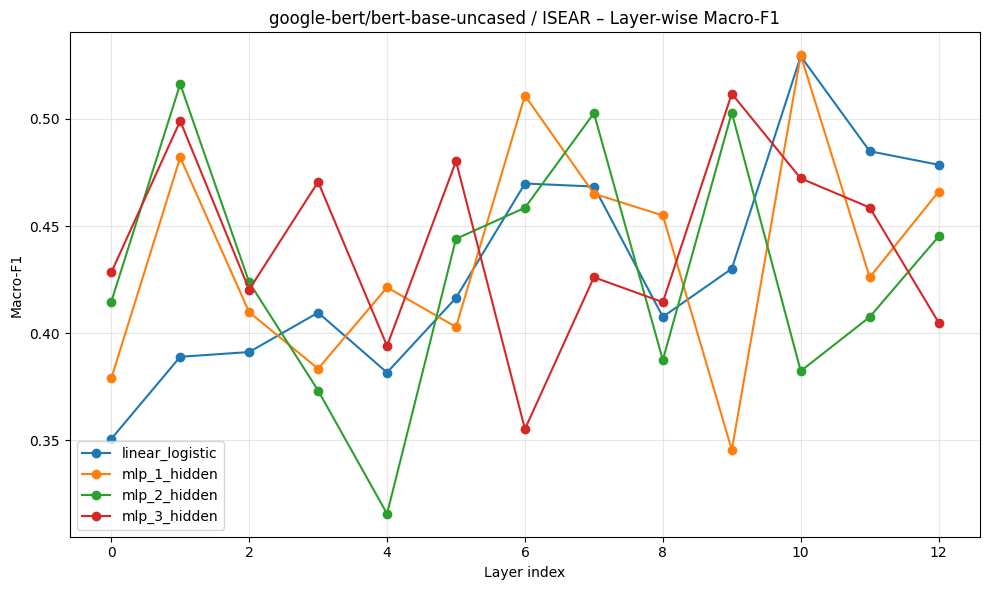

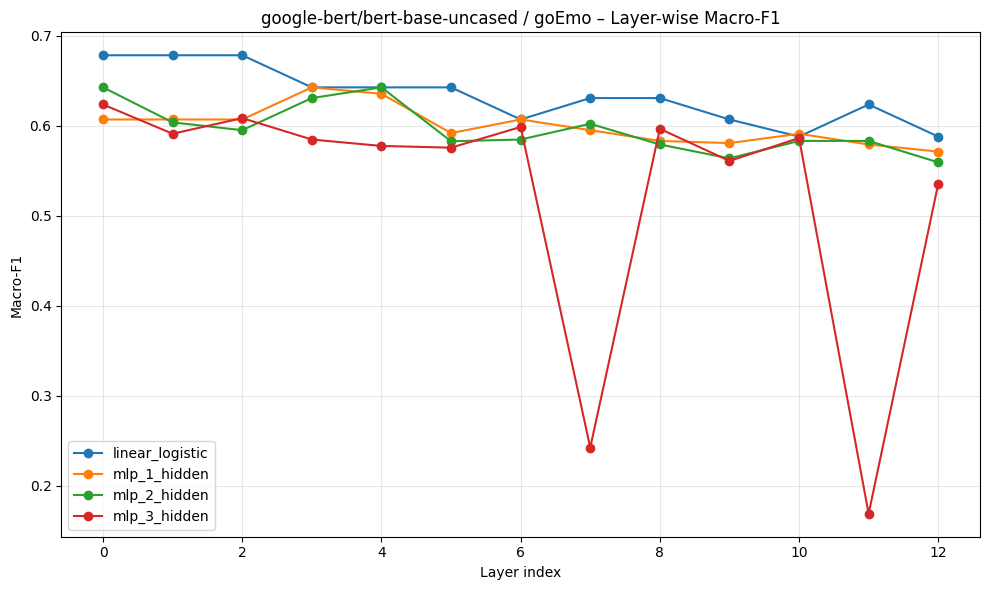

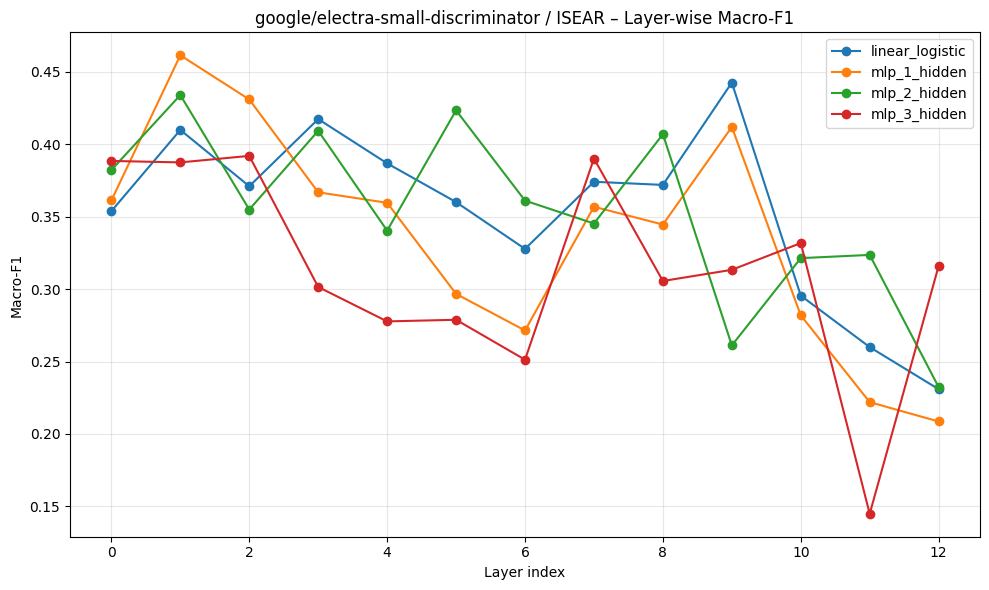

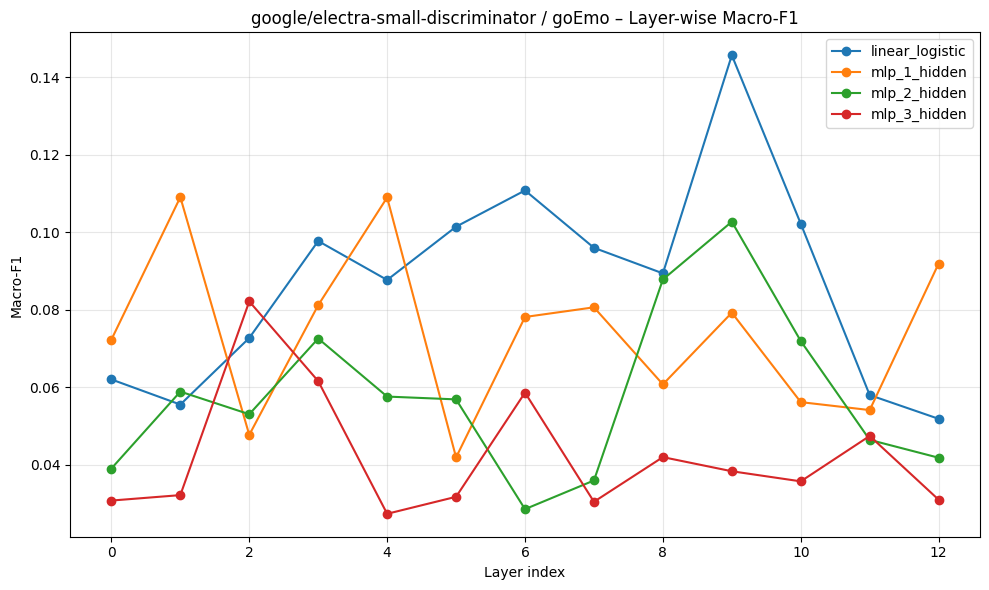

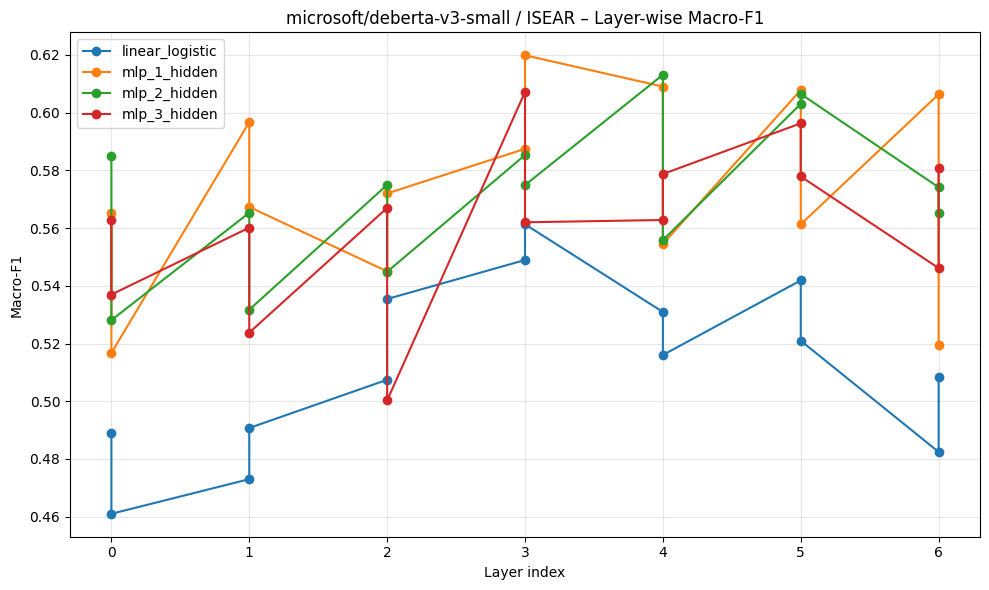

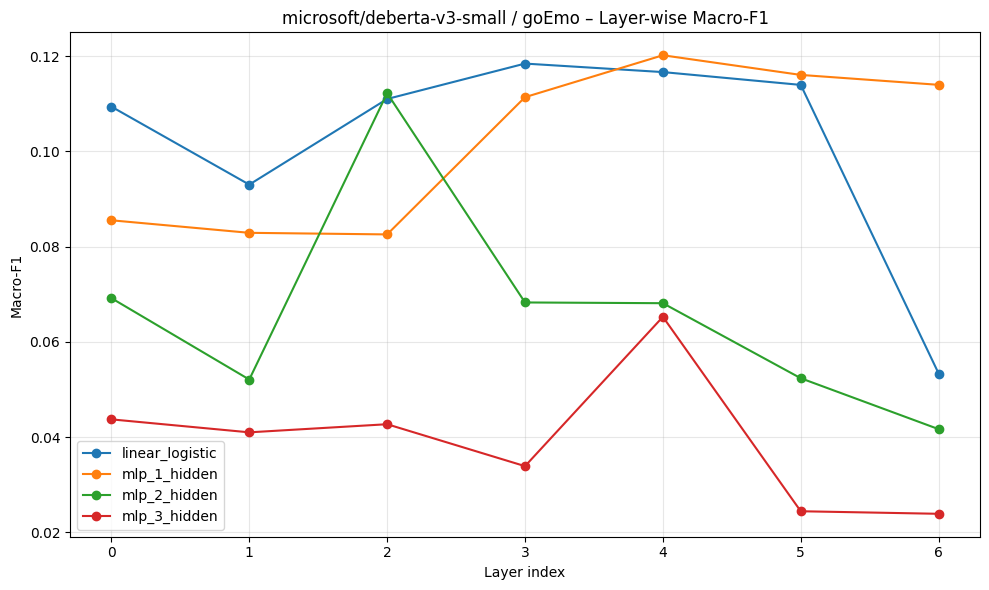

In [7]:
# 1. Layer curves for test macro-F1 per model/dataset
for (model, dataset), group in full.groupby(['model', 'dataset']):
    plt.figure(figsize=(10, 6))
    for probe in group['probe'].unique():
        sub = group[group['probe'] == probe].sort_values('layer_index')
        plt.plot(sub['layer_index'], sub['test_macro_f1'], marker='o', label=probe)
    plt.title(f"{model} / {dataset} – Layer-wise Macro-F1")
    plt.xlabel('Layer index')
    plt.ylabel('Macro-F1')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

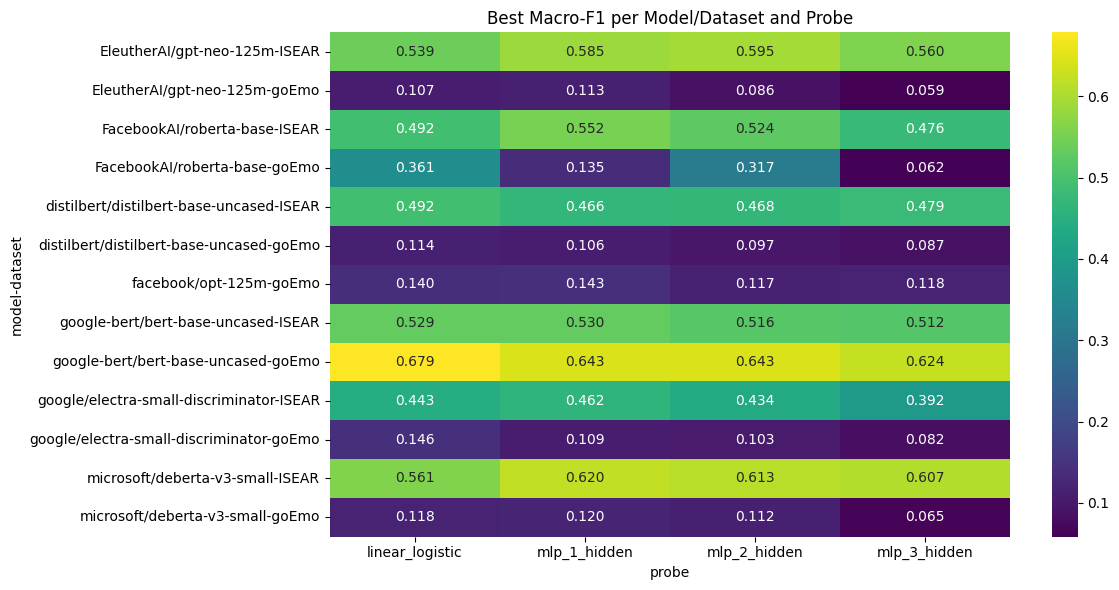

In [8]:
best_layer = full.loc[full.groupby(['probe', 'model', 'dataset'])['test_macro_f1'].idxmax()]
pivot = best_layer.pivot_table(index=['model', 'dataset'], columns='probe', values='test_macro_f1')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='viridis')
plt.title('Best Macro-F1 per Model/Dataset and Probe')
plt.tight_layout()
plt.show()

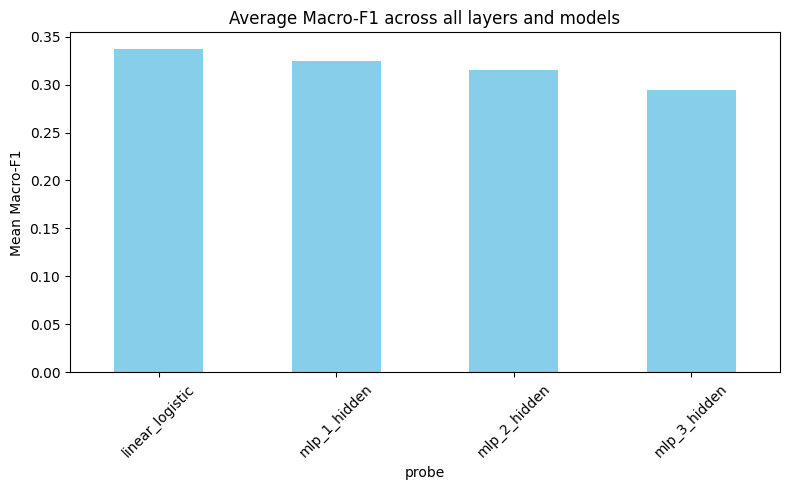

In [9]:
avg = full.groupby('probe')['test_macro_f1'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
avg.plot(kind='bar', color='skyblue')
plt.title('Average Macro-F1 across all layers and models')
plt.ylabel('Mean Macro-F1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()